In [469]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse import linalg

# MATH 461 Unit 3 Project

**Group member**
- Ryan Hsiao
- Fanbo Feng
- Davis Li

## Numerical simulation

In [470]:
# Parameters 
z = 1
alpha = 2.2e-5
# beta = 0.01
beta = 0
T_a = 293.15
r = 1
gamma = 200
sd = 0.1

In [471]:
### The following code is adapted and modified from the original MATLAB code provided by Professor Colin Macdonald in MATH 405 in UBC. ###

# Grid
J = 60
h = 3.0 / J
s = np.linspace(h, 3.0, J)
# k = 0.1 * h
k = 5
xx, yy = np.meshgrid(s, s)
x = xx.flatten()
y = yy.flatten()

# Initial condition
u = np.full((J*J,), T_a)

# Source term
source = ((gamma/z) / (np.sqrt(2*np.pi)*sd)) * np.exp(-((xx-2.8)**2 + (yy-1.5)**2) / (2*sd**2))
source = source.flatten()

In [472]:
### The following code is adapted and modified from the original MATLAB code provided by Professor Colin Macdonald in MATH 405 in UBC. ###

# Matrix Construction (Backward Euler)
N = len(s)
e = np.ones(N)
L1d = sparse.spdiags([e, -2*e, e], [-1, 0, 1], N, N).tocsr()
L1d[0, 0] = -3
L1d[0, 1] = 3
L1d[-1, -1] = -3
L1d[-1, -2] = 3
L1d = (1 / h**2) * L1d
I1d = sparse.eye(N)

L = sparse.kron(I1d, L1d) + sparse.kron(L1d, I1d)
I = sparse.eye(L.shape[0])

A = I - k*alpha*L + k*beta*I 

In [473]:
### The following code is adapted and modified from the original MATLAB code provided by Professor Colin Macdonald in MATH 405 in UBC. ###

# Time-stepping
Tf = 43200
numsteps = int(np.ceil(Tf / k))
t = 0

In [474]:
### The following code is adapted and modified from the original MATLAB code provided by Professor Colin Macdonald in MATH 405 in UBC. ###

# Times we want to capture
# target_times = [0, 0.002, 0.0033, 0.01]
# target_times = [0, 0.5, 1.0, 50.0]
target_times = np.linspace(0, Tf, 4)
snapshots = {}

for n in range(numsteps + 1):
    for target in target_times:
        if np.isclose(t, target, atol=k/2):
            snapshots[target] = u.reshape(xx.shape)
    
    if n < numsteps:
        b = u + k*source
        u = linalg.spsolve(A, b)

        # Make sure the heat does not exceed 1000
        u = np.clip(u, T_a, 1000)

        t += k

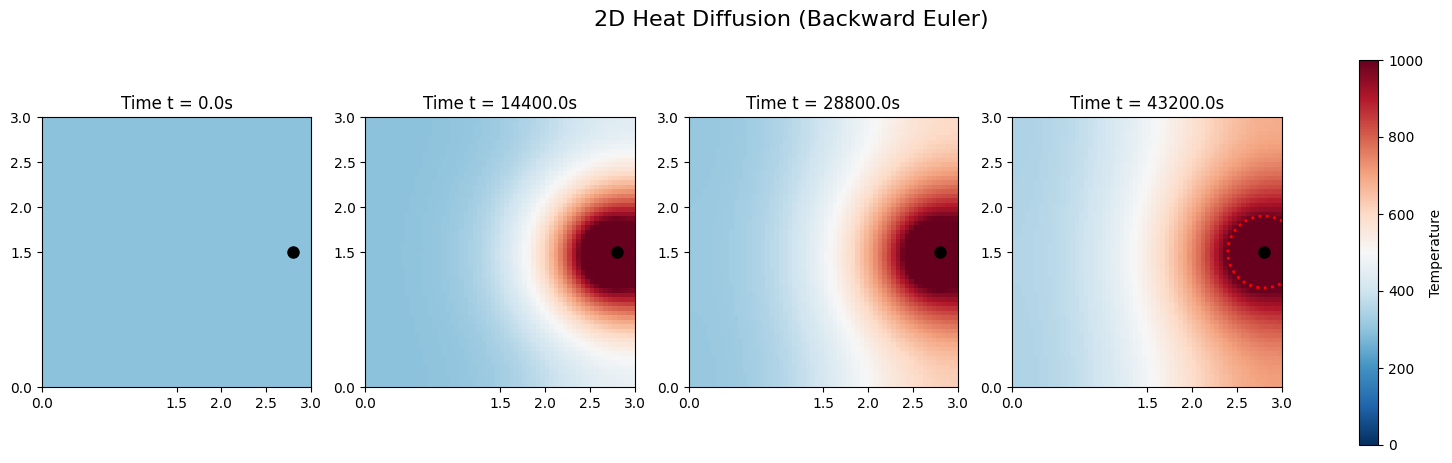

In [475]:
### The following code is adapted and modified from the original MATLAB code provided by Professor Colin Macdonald in MATH 405 in UBC. ###

# Plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, target in enumerate(target_times):
    im = axes[i].imshow(snapshots[target], extent=[0, 3, 0, 3], origin='lower', cmap='RdBu_r', vmin=0, vmax=1000)
    axes[i].plot(2.8, 1.5, 'ko', markersize=8) 
    axes[i].set_title(f'Time t = {target}s')
    axes[i].set_xticks([0, 1.5, 2, 2.5, 3])
    axes[i].set_yticks([0, 1.5, 2, 2.5, 3])
    # axes[i].set_xlim(2, 3)
    # axes[i].set_ylim(1, 2)

fig.colorbar(im, ax=axes.ravel().tolist(), label='Temperature')
plt.suptitle('2D Heat Diffusion (Backward Euler)', fontsize=16)

theta = np.linspace(0, 2*np.pi, 100)
x_circle_1 = 2.8 + 0.4 * np.cos(theta)
y_circle_1 = 1.5 + 0.4 * np.sin(theta)
plt.plot(x_circle_1, y_circle_1, color='red', linestyle=':', linewidth=2, label='Target')

plt.xlim(0, 3)
plt.ylim(0, 3)
plt.show()

## Steady state

Set $u_t=0$

## Numerical stability analysis

Von Neumann stability analysis